> ## Роль в pipeline
>
> **Назначение:** **Leave-One-Out (LOO) supervised validation** для consensus-весов Health Score.
>
> **Что делает:** для каждого observable таргета (`cart_rate`, `session_conversion_rate`, `km_speed_to_cart`):
> - исключает его источник из фичей (LOO)
> - калибрует supervised методы (Ridge / PLS / CCA / Composite) на дельтах
> - валидирует `corr(Δscore_loo, Δtarget)` на хвостовом окне — методологически корректно (без циркулярности)
>
> **Использование:** **НЕ источник production-весов** (это даёт `weight_calibration_consensus.ipynb`). Назначение:
> - second opinion для consensus-весов: совпадают ли supervised LOO веса со statистическим consensus
> - hold-out предсказательная сила: насколько score без таргета предсказывает Δtarget
> - structural input: подтверждение анти-корреляции `Δcart_rate ↔ Δkm_speed_to_cart` (разные оси качества)
>
> **Почему LOO:** после включения `cart_rate` в Health Score (engagement) и `km_median` в quality, наивная supervised-калибровка на этих таргетах стала циркулярной (`score` содержит таргет). LOO исключает источник таргета из фичей — циркулярность уходит, supervised-методы становятся валидны.
>
> **Статус:** **active validation tool**. Производит диагностику для consensus, не сами веса.

# LOO-валидация Health Score через supervised на дельтах

## Зачем

После включения `cart_rate` и `session_conversion_rate` в engagement-группу, а `km_median_time_to_cart_s` в quality, supervised-калибровка с этими наблюдаемыми KPI как таргетами **циркулярна** — score предсказывает свой собственный компонент.

**Решение — Leave-One-Out:** исключаем фичу-источник таргета из feature set, валидируем `Δscore_loo ~ Δtarget` на дельтах.

## Маппинг таргет → исключаемая фича

| Таргет | Источник в Health Score | Исключаем |
|---|---|---|
| `cart_rate` | сама фича (engagement) | `cart_rate` |
| `session_conversion_rate` | сама фича (engagement) | `session_conversion_rate` |
| `km_speed_to_cart = 1/km_median` | трансформация `km_median_time_to_cart_s` (quality) | `km_median_time_to_cart_s` |

**LOO_FEATURES** = все 15 Health Score-фичей минус 3 таргетных источника = **12 фичей**, общий набор для всех методов и всех таргетов.

## Подходы

| # | Метод | Что максимизирует |
|---|---|---|
| 1 | **Ridge per-target** | `corr(Δscore_loo, Δtarget_i)` отдельно для каждого таргета |
| 2 | **PLS multi-target** | `cov(Δscore_loo, ΔY)` со всеми таргетами одновременно |
| 3 | **CCA** | `corr(ΔX_loo·w, ΔY·v)` — оптимальная проекция на стороны X и Y |
| 4 | **Composite** | mean z-нормализованных Δтаргетов → один Ridge |

Все на дельтах, все на LOO_FEATURES (12), все 3 таргета.

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.cross_decomposition import PLSRegression, CCA
from sklearn.model_selection import LeaveOneOut, cross_val_score

warnings.filterwarnings('ignore')
np.random.seed(42)
DATA_DIR = Path('../../data/daily_summaries')
print('OK')

OK


## 1. Загрузка и таргеты

Агрегируем `daily_summaries` (категория → день) с null-aware взвешенным средним.
Два таргета: `cart_rate` (event-based, mean n_cart per session) и `km_speed_to_cart`.

In [2]:
df_cat = pl.read_parquet(str(DATA_DIR / '*.parquet'))

# Все Health Score фичи + контекст для агрегации
AGG_COLS = [
    # base rates (engagement / discovery base)
    'rate_searches', 'rate_views', 'rate_clicks', 'rate_favs',
    'rate_unique_queries', 'multi_category_rate',
    # quality
    'dead_search_rate', 'search_refinement_rate', 'bounce_rate',
    'km_median_time_to_cart_s',
    # funnel transitions
    'view_per_search', 'click_per_view', 'cart_per_click',
    # conversion (targets + features)
    'cart_rate', 'session_conversion_rate',
]
ANTI_METRICS = ['dead_search_rate', 'bounce_rate']  # km_median обрабатываем как target km_speed

# Null-aware weighted aggregation per (date, category) → daily
weighted_aggs = [
    (pl.col(c) * pl.col('n_sessions')).sum().alias(f'_w_{c}') for c in AGG_COLS
]
denom_aggs = [
    pl.when(pl.col(c).is_not_null())
      .then(pl.col('n_sessions')).otherwise(pl.lit(0, dtype=pl.UInt32))
      .sum().alias(f'_d_{c}')
    for c in AGG_COLS
]

daily = (
    df_cat
    .group_by('date')
    .agg([
        pl.col('n_sessions').sum().alias('n_sessions'),
        *weighted_aggs, *denom_aggs,
    ])
    .with_columns([
        pl.when(pl.col(f'_d_{c}') > 0)
          .then(pl.col(f'_w_{c}') / pl.col(f'_d_{c}'))
          .otherwise(None)
          .alias(c)
        for c in AGG_COLS
    ])
    .drop([f'_w_{c}' for c in AGG_COLS] + [f'_d_{c}' for c in AGG_COLS])
    .sort('date')
).to_pandas()
daily['date'] = pd.to_datetime(daily['date'])

# Анти-метрики → инверсии (только для фичей, km_median трансформируется в km_speed как target)
for m in ANTI_METRICS:
    daily[f'{m}_inv'] = 1 - daily[m]

# Целевая фича km_speed_to_cart = 1/km_median
daily['km_speed_to_cart'] = 1.0 / daily['km_median_time_to_cart_s']

# ВСЕ Health Score фичи (15)
ALL_FEATURES = [
    # quality (4 of 6, 2 NLP-pending)
    'dead_search_rate_inv', 'search_refinement_rate', 'bounce_rate_inv',
    'km_median_time_to_cart_s',
    # engagement (8)
    'rate_clicks', 'rate_views', 'rate_favs', 'multi_category_rate',
    'click_per_view', 'cart_per_click', 'cart_rate', 'session_conversion_rate',
    # discovery (3)
    'rate_unique_queries', 'rate_searches', 'view_per_search',
]

# Таргеты и какие источники из ALL_FEATURES исключать
TARGET_SOURCE = {
    'cart_rate':                'cart_rate',
    'session_conversion_rate':  'session_conversion_rate',
    'km_speed_to_cart':         'km_median_time_to_cart_s',
}
TARGET_COLS = list(TARGET_SOURCE.keys())

# LOO_FEATURES = ALL_FEATURES минус все источники таргетов (общий набор для всех методов)
LOO_FEATURES = [f for f in ALL_FEATURES if f not in TARGET_SOURCE.values()]

print(f'Дней:           {len(daily)}')
print(f'ALL_FEATURES:   {len(ALL_FEATURES)} (Health Score без NLP)')
print(f'TARGETS:        {len(TARGET_COLS)} → {TARGET_COLS}')
print(f'LOO_FEATURES:   {len(LOO_FEATURES)} (= ALL минус источники {len(TARGET_SOURCE)} таргетов)')
print(f'NaN:            {daily[ALL_FEATURES + TARGET_COLS].isna().sum().sum()}')
daily[LOO_FEATURES + TARGET_COLS].describe().round(4)

Дней:           61
ALL_FEATURES:   15 (Health Score без NLP)
TARGETS:        3 → ['cart_rate', 'session_conversion_rate', 'km_speed_to_cart']
LOO_FEATURES:   12 (= ALL минус источники 3 таргетов)
NaN:            0


,dead_search_rate_inv,search_refinement_rate,bounce_rate_inv,rate_clicks,rate_views,rate_favs,multi_category_rate,click_per_view,cart_per_click,rate_unique_queries,rate_searches,view_per_search,cart_rate,session_conversion_rate,km_speed_to_cart
count,61.0000,61.0000,61.0000,61.0000,61.0000,61.0000,61.0000,61.0000,61.0000,61.0000,61.0000,61.0000,61.0000,61.0000,61.0000
mean,0.4395,0.5701,0.9629,1.2938,53.4041,0.0441,0.7642,0.0309,1.4437,3.2620,3.5448,13.7541,1.9232,0.4797,0.0044
std,0.0093,0.0077,0.0038,0.1016,5.5322,0.0086,0.0119,0.0009,0.0586,0.2034,0.3384,0.4650,0.0898,0.0137,0.0008
min,0.3974,0.5489,0.9416,1.1149,44.5374,0.0372,0.6873,0.0296,1.2851,3.0131,3.2252,11.9241,1.6638,0.4325,0.0010
25%,0.4356,0.5671,0.9615,1.2259,50.3334,0.0397,0.7619,0.0302,1.4072,3.1323,3.3617,13.5791,1.8974,0.4768,0.0041
50%,0.4400,0.5706,0.9628,1.2718,51.7123,0.0409,0.7649,0.0308,1.4516,3.2059,3.4309,13.7660,1.9322,0.4824,0.0044
75%,0.4440,0.5738,0.9649,1.3162,53.3267,0.0436,0.7682,0.0315,1.4796,3.2877,3.5193,13.8992,1.9722,0.4872,0.0049
max,0.4627,0.5955,0.9688,1.5633,69.7078,0.0697,0.7835,0.0339,1.5462,3.8569,4.6160,15.3814,2.1926,0.5049,0.0073


## 2. EDA: таргеты во времени и их взаимные корреляции

Если все три таргета сильно скоррелированы — multi-target вырождается в single-target.
Хотим, чтобы они подсвечивали **разные оси** качества.

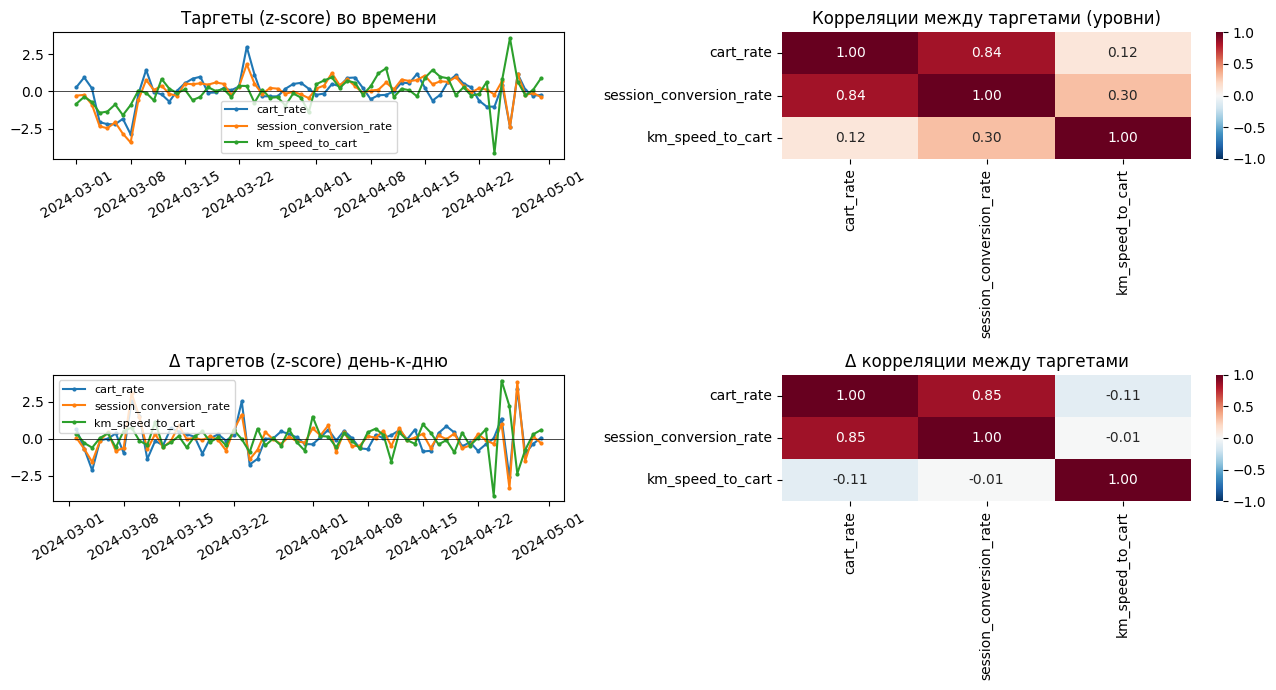

Δ датасет: 60 строк

Если corr(cart_rate, km_speed) в Δ отрицательный — обоснование разделения групп.
Если cart_rate ≈ session_conversion_rate в Δ — частичная избыточность.


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# Уровни таргетов (нормированные)
y_norm = daily[TARGET_COLS].apply(lambda s: (s - s.mean()) / s.std())
for col in TARGET_COLS:
    axes[0, 0].plot(daily['date'], y_norm[col], label=col, marker='o', markersize=2)
axes[0, 0].set_title('Таргеты (z-score) во времени')
axes[0, 0].axhline(0, color='black', lw=0.5)
axes[0, 0].legend(fontsize=8)
axes[0, 0].tick_params(axis='x', rotation=30)

# Корреляции между таргетами на уровнях
sns.heatmap(daily[TARGET_COLS].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[0, 1])
axes[0, 1].set_title('Корреляции между таргетами (уровни)')

# Дельты
daily_delta = daily.copy()
for c in LOO_FEATURES + TARGET_COLS:
    daily_delta[c] = daily[c].diff()
daily_delta = daily_delta.dropna(subset=LOO_FEATURES + TARGET_COLS).reset_index(drop=True)

y_delta_norm = daily_delta[TARGET_COLS].apply(lambda s: (s - s.mean()) / s.std())
for col in TARGET_COLS:
    axes[1, 0].plot(daily_delta['date'], y_delta_norm[col], label=col, marker='o', markersize=2)
axes[1, 0].set_title('Δ таргетов (z-score) день-к-дню')
axes[1, 0].axhline(0, color='black', lw=0.5)
axes[1, 0].legend(fontsize=8)
axes[1, 0].tick_params(axis='x', rotation=30)

# Δ-корреляции между таргетами
sns.heatmap(daily_delta[TARGET_COLS].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[1, 1])
axes[1, 1].set_title('Δ корреляции между таргетами')

plt.tight_layout()
plt.show()
print(f'Δ датасет: {len(daily_delta)} строк')
print(f'\nЕсли corr(cart_rate, km_speed) в Δ отрицательный — обоснование разделения групп.')
print(f'Если cart_rate ≈ session_conversion_rate в Δ — частичная избыточность.')

## 3. Подготовка матриц X, Y на дельтах

Стандартизуем и фичи, и таргеты — для PLS/CCA это обязательно, для Ridge — удобство интерпретации.

In [4]:
# X на LOO_FEATURES (12), Y на TARGET_COLS (3)
X_raw = daily_delta[LOO_FEATURES].values
Y_raw = daily_delta[TARGET_COLS].values

x_scaler = StandardScaler().fit(X_raw)
y_scaler = StandardScaler().fit(Y_raw)
X = x_scaler.transform(X_raw)
Y = y_scaler.transform(Y_raw)

print(f'X: {X.shape}  Y: {Y.shape}')
print(f'\nΔ corrs (X_loo vs каждый таргет):')
for i, t in enumerate(TARGET_COLS):
    corrs = pd.Series(
        [np.corrcoef(X[:, j], Y[:, i])[0, 1] for j in range(X.shape[1])],
        index=LOO_FEATURES
    ).sort_values(ascending=False)
    print(f'\n  {t}:')
    print('   ', corrs.round(3).to_dict())

X: (60, 12)  Y: (60, 3)

Δ corrs (X_loo vs каждый таргет):

  cart_rate:
    {'dead_search_rate_inv': 0.87, 'bounce_rate_inv': 0.722, 'search_refinement_rate': 0.712, 'multi_category_rate': 0.696, 'view_per_search': 0.533, 'rate_clicks': 0.431, 'rate_unique_queries': 0.402, 'cart_per_click': 0.372, 'rate_views': 0.357, 'rate_searches': 0.281, 'rate_favs': 0.149, 'click_per_view': -0.348}

  session_conversion_rate:
    {'dead_search_rate_inv': 0.783, 'bounce_rate_inv': 0.769, 'multi_category_rate': 0.764, 'view_per_search': 0.635, 'cart_per_click': 0.621, 'search_refinement_rate': 0.493, 'rate_clicks': 0.152, 'rate_unique_queries': 0.118, 'rate_views': 0.099, 'rate_searches': 0.009, 'rate_favs': -0.051, 'click_per_view': -0.51}

  km_speed_to_cart:
    {'cart_per_click': 0.15, 'search_refinement_rate': 0.101, 'click_per_view': 0.033, 'rate_searches': -0.13, 'rate_unique_queries': -0.135, 'rate_favs': -0.155, 'rate_views': -0.161, 'view_per_search': -0.165, 'rate_clicks': -0.188, 'dead_

## 4. Ridge per-target (LOO)

Для каждого таргета `T` отдельно: Ridge на 12 LOO-фичах с LOO CV (MAE), веса = `|coef|`.
Сравним коэффициенты между таргетами — покажет, насколько они согласованы (ожидаем что cart_rate ↔ km_speed противоречат).

In [5]:
def ridge_loo_weights(X, y, alphas=(0.1, 0.5, 1.0, 5.0, 10.0, 50.0)):
    loo = LeaveOneOut()
    best_a, best_mae = None, np.inf
    for a in alphas:
        mae = -cross_val_score(Ridge(alpha=a), X, y, cv=loo,
                               scoring='neg_mean_absolute_error').mean()
        if mae < best_mae:
            best_mae, best_a = mae, a
    ridge = Ridge(alpha=best_a).fit(X, y)
    return ridge, best_a, best_mae

single_target_results = {}
for i, t in enumerate(TARGET_COLS):
    ridge, a, mae = ridge_loo_weights(X, Y[:, i])
    coefs = pd.Series(ridge.coef_, index=LOO_FEATURES)
    weights = coefs.abs() / coefs.abs().sum() if coefs.abs().sum() > 0 else coefs.abs()
    single_target_results[t] = {'coefs': coefs, 'weights': weights, 'alpha': a, 'mae': mae}
    print(f'{t:30s}  α={a:5.1f}  LOO MAE={mae:.4f}')

coefs_table = pd.DataFrame({t: r['coefs'] for t, r in single_target_results.items()}).round(3)
weights_table = pd.DataFrame({t: r['weights'] for t, r in single_target_results.items()}).round(3)

print('\nRidge коэффициенты (знак = направление влияния на Δ таргета):')
print(coefs_table)
print('\nRidge веса (|coef| нормированные):')
print(weights_table)

cart_rate                       α=  1.0  LOO MAE=0.1462
session_conversion_rate         α=  0.5  LOO MAE=0.2314


km_speed_to_cart                α=  5.0  LOO MAE=0.6082

Ridge коэффициенты (знак = направление влияния на Δ таргета):
                        cart_rate  session_conversion_rate  km_speed_to_cart
dead_search_rate_inv        0.442                    0.459            -0.338
search_refinement_rate      0.337                    0.193             0.264
bounce_rate_inv             0.206                    0.145            -0.077
rate_clicks                 0.248                    0.184            -0.025
rate_views                  0.087                   -0.272            -0.025
rate_favs                  -0.189                    0.289            -0.096
multi_category_rate        -0.066                    0.022            -0.174
click_per_view              0.052                    0.083             0.031
cart_per_click              0.350                    0.572             0.163
rate_unique_queries         0.144                   -0.163             0.069
rate_searches              -0.041 

## 5. PLS multi-target (LOO)

**PLS Regression** на LOO-фичах: латентные компоненты максимизируют `cov(t, Y)` со ВСЕМИ 3 таргетами одновременно. Первая компонента → веса фичей.
Поскольку cart_rate ⊥ km_speed на дельтах, PLS должен найти компромиссное направление.

In [6]:
pls = PLSRegression(n_components=1, scale=False).fit(X, Y)
pls_loadings = pd.Series(pls.x_weights_[:, 0], index=LOO_FEATURES)

# Знак: выравниваем по среднему corr с таргетами
score_pls = X @ pls_loadings.values
mean_corr = np.mean([np.corrcoef(score_pls, Y[:, i])[0, 1] for i in range(Y.shape[1])])
if mean_corr < 0:
    pls_loadings = -pls_loadings
    score_pls = -score_pls
    mean_corr = -mean_corr

pls_weights = pls_loadings.abs() / pls_loadings.abs().sum()

print(f'PLS компонента: avg corr со всеми Δ-таргетами = {mean_corr:.3f}')
print('\nPLS x_weights (знак = направление):')
print(pls_loadings.sort_values(ascending=False).round(3))
print('\nPLS веса (|x_weights| нормированные):')
print(pls_weights.sort_values(ascending=False).round(3))

PLS компонента: avg corr со всеми Δ-таргетами = 0.500

PLS x_weights (знак = направление):
dead_search_rate_inv      0.470
bounce_rate_inv           0.425
multi_category_rate       0.417
view_per_search           0.331
search_refinement_rate    0.327
cart_per_click            0.263
rate_clicks               0.174
rate_unique_queries       0.153
rate_views                0.137
rate_searches             0.090
rate_favs                 0.038
click_per_view           -0.237
dtype: float64

PLS веса (|x_weights| нормированные):
dead_search_rate_inv      0.154
bounce_rate_inv           0.139
multi_category_rate       0.136
view_per_search           0.108
search_refinement_rate    0.107
cart_per_click            0.086
click_per_view            0.077
rate_clicks               0.057
rate_unique_queries       0.050
rate_views                0.045
rate_searches             0.029
rate_favs                 0.012
dtype: float64


## 6. CCA (LOO)

**Canonical Correlation Analysis** на LOO-фичах: ищет проекции `Xw` (фичи) и `Yv` (таргеты), максимизирующие `corr(Xw, Yv)`.
В присутствии анти-коррелированных таргетов CCA может «выбрать» одну ось как доминирующую (как мы видели — `rate_carts` тогда раздули вес).

In [7]:
cca = CCA(n_components=1, scale=False).fit(X, Y)
cca_loadings = pd.Series(cca.x_weights_[:, 0], index=LOO_FEATURES)
cca_target_loadings = pd.Series(cca.y_weights_[:, 0], index=TARGET_COLS)

score_cca = X @ cca_loadings.values
y_canon = Y @ cca_target_loadings.values
canon_corr = np.corrcoef(score_cca, y_canon)[0, 1]

if canon_corr < 0:
    cca_loadings = -cca_loadings
    canon_corr = -canon_corr

cca_weights = cca_loadings.abs() / cca_loadings.abs().sum()

print(f'CCA каноническая корреляция: {abs(canon_corr):.3f}')
print(f'\nCCA веса таргетов (как они комбинируются в каноническую переменную):')
print(cca_target_loadings.round(3))
print(f'\nCCA x_weights (фичи, знак = направление):')
print(cca_loadings.sort_values(ascending=False).round(3))
print('\nCCA веса фичей (|x_weights| нормированные):')
print(cca_weights.sort_values(ascending=False).round(3))

CCA каноническая корреляция: 0.994

CCA веса таргетов (как они комбинируются в каноническую переменную):
cart_rate                 -0.958
session_conversion_rate   -0.288
km_speed_to_cart          -0.018
dtype: float64

CCA x_weights (фичи, знак = направление):
rate_searches             0.673
rate_views                0.205
multi_category_rate       0.022
view_per_search           0.010
click_per_view           -0.001
rate_favs                -0.005
dead_search_rate_inv     -0.048
bounce_rate_inv          -0.049
search_refinement_rate   -0.065
cart_per_click           -0.131
rate_clicks              -0.401
rate_unique_queries      -0.563
dtype: float64

CCA веса фичей (|x_weights| нормированные):
rate_searches             0.310
rate_unique_queries       0.259
rate_clicks               0.185
rate_views                0.094
cart_per_click            0.060
search_refinement_rate    0.030
bounce_rate_inv           0.023
dead_search_rate_inv      0.022
multi_category_rate       0.010
view_p

## 7. Composite (LOO)

z-нормализованные Δтаргеты усредняются → один Ridge на LOO-фичах. Эквивалент «все таргеты одинаково важны».
При наличии анти-коррелированных таргетов composite-таргет может схлопнуться (cart_rate +1 и km_speed −1 взаимно компенсируются).

In [8]:
y_combo = Y.mean(axis=1)  # Y уже z-нормализован
ridge_combo, alpha_combo, mae_combo = ridge_loo_weights(X, y_combo)

combo_coefs = pd.Series(ridge_combo.coef_, index=LOO_FEATURES)
combo_weights = combo_coefs.abs() / combo_coefs.abs().sum() if combo_coefs.abs().sum() > 0 else combo_coefs.abs()

print(f'Composite Ridge: α={alpha_combo}, LOO MAE={mae_combo:.4f}')
print(f'Composite-таргет = mean(z(cart_rate), z(session_conversion_rate), z(km_speed))')
print('\nCoefs (Δy_combo ~ ΔX_loo):')
print(combo_coefs.sort_values(ascending=False).round(3))
print('\nComposite веса:')
print(combo_weights.sort_values(ascending=False).round(3))

Composite Ridge: α=1.0, LOO MAE=0.2340
Composite-таргет = mean(z(cart_rate), z(session_conversion_rate), z(km_speed))

Coefs (Δy_combo ~ ΔX_loo):
cart_per_click            0.364
search_refinement_rate    0.319
view_per_search           0.185
rate_clicks               0.149
bounce_rate_inv           0.143
click_per_view            0.086
rate_unique_queries       0.074
dead_search_rate_inv      0.035
rate_searches             0.006
rate_favs                -0.048
multi_category_rate      -0.063
rate_views               -0.094
dtype: float64

Composite веса:
cart_per_click            0.232
search_refinement_rate    0.204
view_per_search           0.118
rate_clicks               0.095
bounce_rate_inv           0.091
rate_views                0.060
click_per_view            0.055
rate_unique_queries       0.047
multi_category_rate       0.040
rate_favs                 0.031
dead_search_rate_inv      0.023
rate_searches             0.004
dtype: float64


## 8. Сравнение всех LOO-методов

Все 4 метода работают на одних и тех же LOO-фичах (12). Сравниваем веса между собой.
Если методы дают разные веса → методологическая чувствительность; если близкие → стабильно.

In [9]:
comparison = pd.DataFrame({
    f'Ridge ({t})': single_target_results[t]['weights'] for t in TARGET_COLS
})
comparison['PLS']       = pls_weights
comparison['CCA']       = cca_weights
comparison['Composite'] = combo_weights
comparison = comparison.round(4)

print(comparison.sort_values('Composite', ascending=False).to_string())

                        Ridge (cart_rate)  Ridge (session_conversion_rate)  Ridge (km_speed_to_cart)     PLS     CCA  Composite
cart_per_click                     0.1579                           0.2253                    0.1037  0.0858  0.0601     0.2322
search_refinement_rate             0.1517                           0.0759                    0.1680  0.1068  0.0297     0.2037
view_per_search                    0.0257                           0.0455                    0.1705  0.1082  0.0048     0.1180
rate_clicks                        0.1119                           0.0724                    0.0157  0.0568  0.1846     0.0948
bounce_rate_inv                    0.0930                           0.0572                    0.0490  0.1388  0.0226     0.0914
rate_views                         0.0393                           0.1070                    0.0159  0.0448  0.0942     0.0601
click_per_view                     0.0235                           0.0325                    0.0196  0.

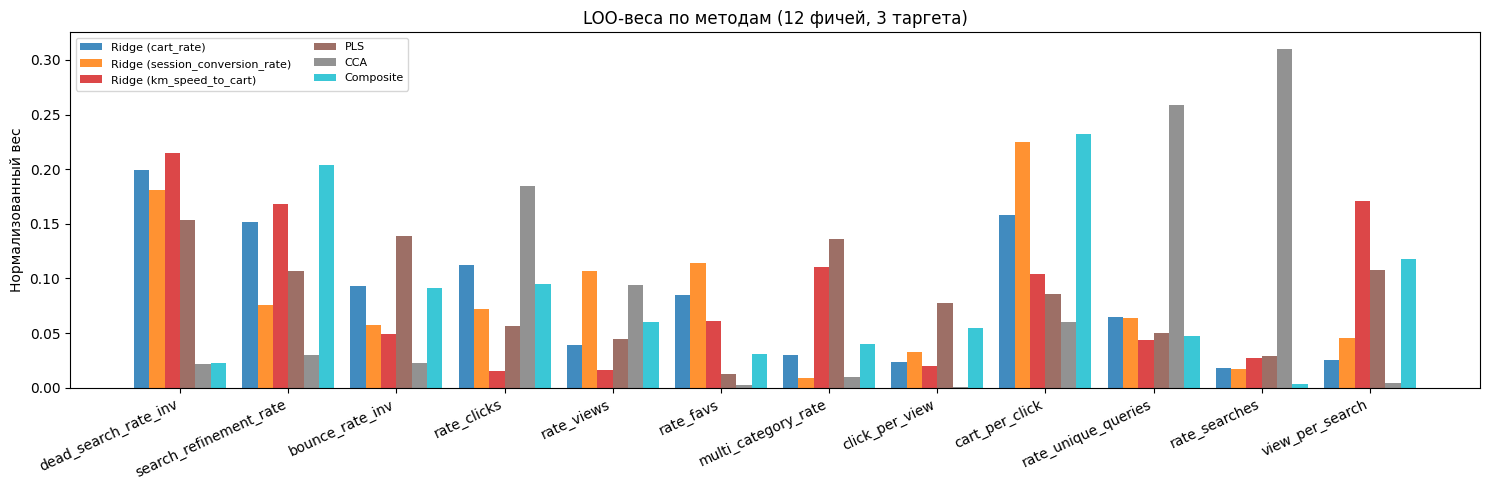

In [10]:
weight_cols = list(comparison.columns)
x = np.arange(len(LOO_FEATURES))
n_methods = len(weight_cols)
width = 0.85 / n_methods
colors_list = cm.tab10(np.linspace(0, 0.9, n_methods))

fig, ax = plt.subplots(figsize=(15, 5))
for i, (col, color) in enumerate(zip(weight_cols, colors_list)):
    ax.bar(x + i * width, comparison.loc[LOO_FEATURES, col].values,
           width, label=col, color=color, alpha=0.85)

ax.set_xticks(x + width * (n_methods - 1) / 2)
ax.set_xticklabels(LOO_FEATURES, rotation=25, ha='right')
ax.set_ylabel('Нормализованный вес')
ax.set_title('LOO-веса по методам (12 фичей, 3 таргета)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 9. Hold-out валидация на хвостовом окне

Для каждого метода считаем `Δscore_loo = ΔX_loo @ w_signed` на последних 20 днях и `corr` с **каждым** Δ-таргетом отдельно.

**Это методологически корректно:** Δscore_loo не содержит ни одного из 3 таргетов в своих фичах by construction → корреляция не циркулярна.

`mean|corr|` показывает, насколько score одновременно ловит все 3 оси.

In [11]:
multi_ensemble = comparison[['PLS', 'CCA', 'Composite']].mean(axis=1)
multi_ensemble = multi_ensemble / multi_ensemble.sum()

print('=== Multi-target Ensemble (PLS+CCA+Composite) ===')
print(multi_ensemble.sort_values(ascending=False).round(4))

n_val = 20
X_val = X[-n_val:]
Y_val = Y[-n_val:]

# Подписные signed-веса для построения score (не нормированные |coef|)
all_weights_signed = {
    f'Ridge_{t}': single_target_results[t]['coefs'] for t in TARGET_COLS
}
all_weights_signed['PLS']       = pls_loadings
all_weights_signed['CCA']       = cca_loadings
all_weights_signed['Composite'] = combo_coefs

print(f'\nLOO-валидация на последних {n_val} днях (Δ corr с каждым Δ-таргетом):')
header = f'{"Метод":30s}  ' + '  '.join(f'{t:>22s}' for t in TARGET_COLS) + '   mean|corr|'
print(header)
print('-' * len(header))
for name, w in all_weights_signed.items():
    score = X_val @ w.reindex(LOO_FEATURES).fillna(0).values
    corrs = [np.corrcoef(score, Y_val[:, i])[0, 1] for i in range(len(TARGET_COLS))]
    mean_abs = np.mean(np.abs(corrs))
    print(f'{name:30s}  ' + '  '.join(f'{c:+22.3f}' for c in corrs) + f'   {mean_abs:.3f}')

=== Multi-target Ensemble (PLS+CCA+Composite) ===
cart_per_click            0.1260
rate_unique_queries       0.1188
rate_searches             0.1142
search_refinement_rate    0.1134
rate_clicks               0.1121
bounce_rate_inv           0.0843
view_per_search           0.0770
rate_views                0.0664
dead_search_rate_inv      0.0661
multi_category_rate       0.0622
click_per_view            0.0444
rate_favs                 0.0151
dtype: float64

LOO-валидация на последних 20 днях (Δ corr с каждым Δ-таргетом):
Метод                                        cart_rate  session_conversion_rate        km_speed_to_cart   mean|corr|
--------------------------------------------------------------------------------------------------------------------
Ridge_cart_rate                                 +0.995                  +0.902                  -0.261   0.719
Ridge_session_conversion_rate                   +0.942                  +0.982                  -0.308   0.744
Ridge_km_speed_to

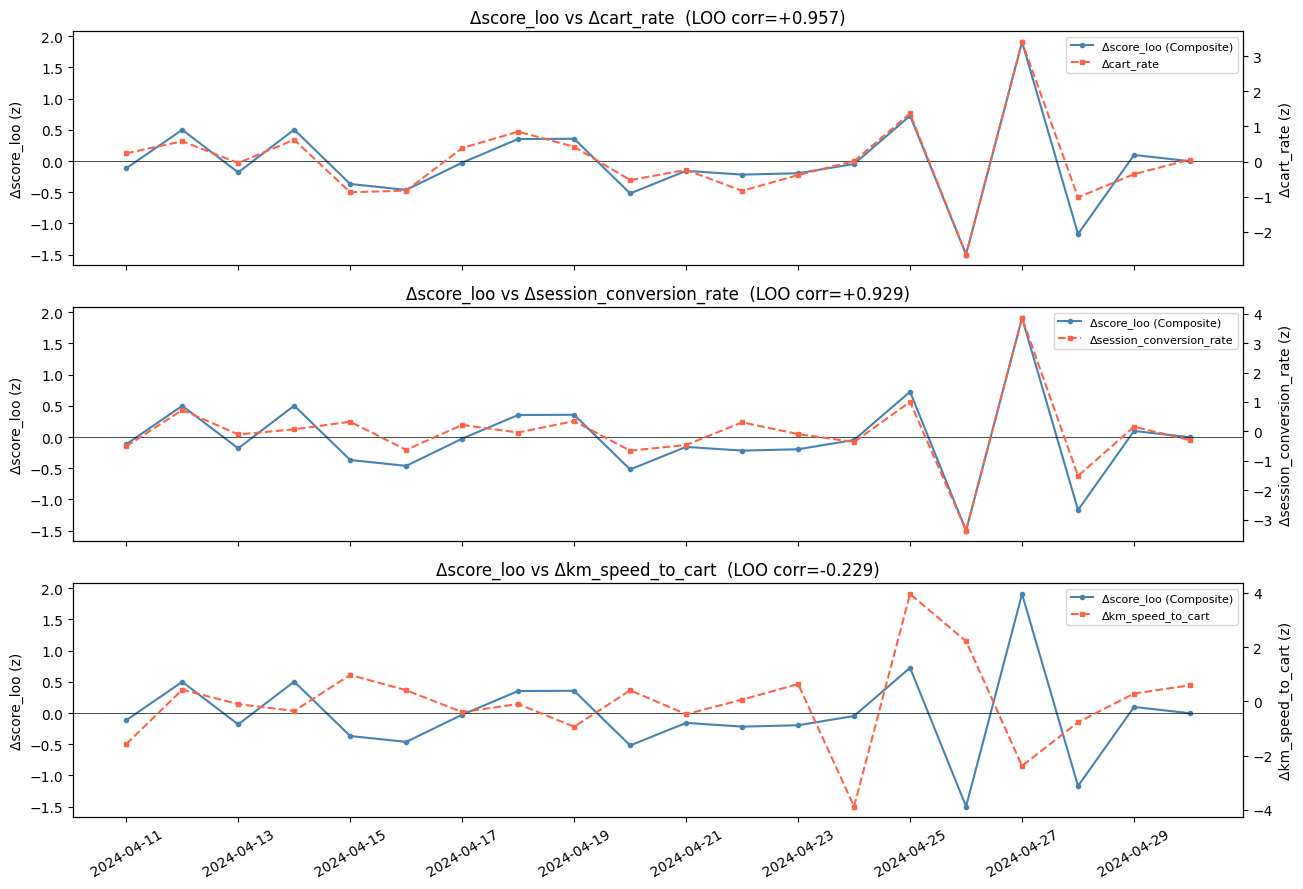

In [12]:
# График: Δscore vs Δтаргеты на хвосте (для Composite — самый «универсальный»)
dates_val = daily_delta['date'].values[-n_val:]
score_combo = X_val @ combo_coefs.reindex(LOO_FEATURES).fillna(0).values

fig, axes = plt.subplots(len(TARGET_COLS), 1, figsize=(13, 3 * len(TARGET_COLS)), sharex=True)
if len(TARGET_COLS) == 1:
    axes = [axes]

for ax, (i, t) in zip(axes, enumerate(TARGET_COLS)):
    corr = np.corrcoef(score_combo, Y_val[:, i])[0, 1]
    ax.plot(dates_val, score_combo, label=f'Δscore_loo (Composite)', color='steelblue', marker='o', markersize=3)
    ax2 = ax.twinx()
    ax2.plot(dates_val, Y_val[:, i], label=f'Δ{t}', color='tomato', linestyle='--', marker='s', markersize=3)
    ax.set_ylabel('Δscore_loo (z)')
    ax2.set_ylabel(f'Δ{t} (z)')
    ax.set_title(f'Δscore_loo vs Δ{t}  (LOO corr={corr:+.3f})')
    ax.axhline(0, color='black', lw=0.5)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')

axes[-1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 10. Что в итоге (LOO)

**Что валидирует LOO:**
- Δscore_loo = функция 12 LOO-фичей (без `cart_rate`, `session_conversion_rate`, `km_median`)
- corr(Δscore_loo, Δtarget) на хвосте — **методологически корректная** оценка предсказательной силы

**Как читать сравнение методов (секция 8):**
- Близкие веса между методами → стабильная LOO-калибровка
- Сильные расхождения → методологическая чувствительность; повод копать

**Hold-out валидация (секция 9):**
- Если Ridge_cart_rate даёт высокую corr с Δcart_rate, а Ridge_km_speed — высокую с Δkm_speed → таргеты тянут в **разные стороны** (что мы знали из анти-корреляции)
- Multi-target методы (PLS / CCA / Composite) ищут компромисс — обычно средние corr со всеми таргетами, но не максимум ни с одним
- `mean|corr|` показывает универсальность

**Что это даёт consensus-весам (production):**
- Если LOO supervised-веса похожи на consensus-веса (на тех же 12 фичах) — разные методологии согласованы, метрика устойчива
- Если расходятся — diagnostic, повод понять что важнее: stat-согласованность (consensus) или предсказательность (delta)

Сами LOO-веса **не идут в production** — production использует consensus на всех 15 фичах. LOO — это **второе мнение**.